In [ ]:
# %% Setup - load both the zero-shot base model and the fine-tuned model
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
os.environ.setdefault("OMP_NUM_THREADS", "1")

from pathlib import Path

import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import torch
from chronos import Chronos2Pipeline

from DP_cstr_data import load_cstr_data, STATE_COLUMNS, EXOG_COLUMNS

LOCAL_CKPT = "chronos-2-finetuned-final"                  # written by Chronos2-FineTune.ipynb
HF_REPO_ID = os.environ.get("CHRONOS_FT_REPO", "")        # e.g. "your-hf-username/chronos-2-cstr-lora"


def resolve_finetuned_checkpoint(local_dir=LOCAL_CKPT, repo_id=HF_REPO_ID):
    """Local checkpoint if present, else pull it from the Hub. Fails loudly with what to do."""
    if Path(local_dir).is_dir():
        print(f"Using local fine-tuned checkpoint: {local_dir}")
        return local_dir

    if not repo_id:
        raise FileNotFoundError(
            f"No fine-tuned checkpoint found.\n"
            f"  '{local_dir}/' does not exist here, and CHRONOS_FT_REPO is not set.\n"
            f"  The checkpoint is gitignored, so it does not travel with the repo.\n"
            f"Fix by one of:\n"
            f"  1. Set CHRONOS_FT_REPO to the Hugging Face repo pushed by Chronos2-FineTune.ipynb,\n"
            f"     e.g. os.environ['CHRONOS_FT_REPO'] = 'your-username/chronos-2-cstr-lora'\n"
            f"  2. Copy '{local_dir}/' across from the machine that ran the fine-tune.\n"
            f"  3. Re-run Chronos2-FineTune.ipynb here (needs a GPU; produces different weights)."
        )

    from huggingface_hub import snapshot_download
    from huggingface_hub.errors import HfHubHTTPError

    try:
        path = snapshot_download(repo_id=repo_id, repo_type="model")
    except HfHubHTTPError as exc:
        raise FileNotFoundError(
            f"Could not download '{repo_id}' from the Hugging Face Hub: {exc}\n"
            f"If the repo is private, authenticate first: `hf auth login` (or set HF_TOKEN)."
        ) from exc
    print(f"Using Hub checkpoint {repo_id} (cached at {path})")
    return path


CHECKPOINT = resolve_finetuned_checkpoint()

# The checkpoint is a LoRA adapter, so peft is needed to merge it back onto the base model.
try:
    import peft  # noqa: F401
except ImportError as exc:
    raise ImportError(
        "The fine-tuned checkpoint is a LoRA adapter and requires `peft` to load. "
        "Install it into this environment: pip install peft"
    ) from exc

device = "cuda" if torch.cuda.is_available() else "cpu"
zeroshot_pipeline = Chronos2Pipeline.from_pretrained("amazon/chronos-2", device_map=device)
# import_allowlist: peft's AutoPeftModel blocks auto-importing arbitrary model classes by default;
# this is our own locally-trained LoRA adapter, so allowing its module is safe.
finetuned_pipeline = Chronos2Pipeline.from_pretrained(
    CHECKPOINT, device_map=device, import_allowlist=["chronos.chronos2.model"]
)
print(f"Loaded zero-shot and fine-tuned Chronos-2 on {device}")


In [2]:
# %% Load the original simulation as the held-out comparison set - never used for fine-tuning
DOWNSAMPLE = 20   # must match FACTOR in CSTR-Downsample.ipynb
df, _ = load_cstr_data(downsample=DOWNSAMPLE)
n = len(df)

flags = {col: df[f"{col}_active"].to_numpy() for col in EXOG_COLUMNS.values()}

events = []
for name, flag in flags.items():
    active = np.where(flag > 0)[0]
    if len(active) == 0:
        continue
    breaks = np.where(np.diff(active) > 1)[0]
    starts = np.concatenate([[active[0]], active[breaks + 1]])
    ends = np.concatenate([active[breaks], [active[-1]]])
    events += [(s, e, name) for s, e in zip(starts, ends)]
events.sort()
print(f"Found {len(events)} fault events across {len(flags)} fault types")

Found 22 fault events across 6 fault types


In [3]:
# %% Pick representative events: one per fault type, plus a second occurrence if it went the opposite direction
BUFFER = 100          # matches Chronos2-Forecast.ipynb
PLOT_LEAD_IN = 500    # matches Chronos2-Forecast.ipynb

def event_direction(start, end, col):
    baseline = df[col].iloc[max(0, start - BUFFER):start].mean()
    during = df[col].iloc[start:end + 1].mean()
    return 1 if during >= baseline else -1

by_fault = {}
for start, end, col in events:
    by_fault.setdefault(col, []).append((start, end, col, event_direction(start, end, col)))

selected = []
for col, occurrences in by_fault.items():
    occurrences.sort(key=lambda e: e[0])
    seen_dirs = {}
    for occ in occurrences:
        seen_dirs[occ[3]] = occ   # keep the latest (most context available) occurrence per direction
    selected += list(seen_dirs.values())
selected.sort(key=lambda e: e[0])

print(f"Selected {len(selected)} rows for comparison:")
for start, end, col, direction in selected:
    print(f"  {col}: {'up' if direction > 0 else 'down'}, samples [{start}, {end}]")

Selected 9 rows for comparison:
  T_CF: up, samples [1089, 1233]
  T_F: down, samples [1282, 1404]
  T_CF: down, samples [2999, 3162]
  Q_F: down, samples [3203, 3319]
  U_Ac: down, samples [3760, 3929]
  Q_F: up, samples [4039, 4173]
  E_R: up, samples [4195, 4301]
  C_F: down, samples [4415, 4611]
  T_F: up, samples [4744, 4887]


In [4]:
# %% Forecast each selected event with both pipelines
def pick_representative_state(context_df, truth_df):
    best_col, best_score = None, -np.inf
    for col in STATE_COLUMNS.values():
        tail = context_df[col].iloc[-PLOT_LEAD_IN:]
        baseline_std = tail.std() or 1e-9
        baseline_mean = tail.mean()
        score = (truth_df[col] - baseline_mean).abs().max() / baseline_std
        if score > best_score:
            best_col, best_score = col, score
    return best_col

rows = []
for start, end, fault_col, direction in selected:
    split = max(start - BUFFER, 0)
    horizon = min((end - split) + 500, zeroshot_pipeline.model_prediction_length, n - split)

    context_df = df.iloc[:split].copy()
    future_df = df.iloc[split:split + horizon][["item_id", "timestamp"] + list(EXOG_COLUMNS.values())].copy()
    truth_df = df.iloc[split:split + horizon].copy()

    state_col = pick_representative_state(context_df, truth_df)

    preds = {}
    for label, pipe in [("zero-shot", zeroshot_pipeline), ("fine-tuned", finetuned_pipeline)]:
        pred_df = pipe.predict_df(
            context_df, future_df=future_df, prediction_length=horizon,
            quantile_levels=[0.1, 0.5, 0.9], id_column="item_id", timestamp_column="timestamp",
            target=list(STATE_COLUMNS.values()),
        )
        sub = pred_df[pred_df["target_name"] == state_col].reset_index(drop=True)
        mae = np.mean(np.abs(sub["predictions"].values - truth_df[state_col].values))
        preds[label] = (sub, mae)

    rows.append(dict(fault=fault_col, direction=direction, state=state_col,
                      context_df=context_df, truth_df=truth_df, preds=preds))
    print(f"{fault_col} ({'up' if direction > 0 else 'down'}) -> {state_col}: "
          f"zero-shot MAE={preds['zero-shot'][1]:.5g}, fine-tuned MAE={preds['fine-tuned'][1]:.5g}")

T_CF (up) -> C_A: zero-shot MAE=0.0065091, fine-tuned MAE=0.0035922
T_F (down) -> C_A: zero-shot MAE=0.0077264, fine-tuned MAE=0.0043127


T_CF (down) -> h: zero-shot MAE=0.00014855, fine-tuned MAE=7.314e-05


Q_F (down) -> h: zero-shot MAE=0.00019812, fine-tuned MAE=8.4366e-05


U_Ac (down) -> Qc: zero-shot MAE=0.017913, fine-tuned MAE=0.0071333


Q_F (up) -> Q: zero-shot MAE=0.017629, fine-tuned MAE=0.0079848


E_R (up) -> T: zero-shot MAE=1.8654, fine-tuned MAE=0.56623


C_F (down) -> T: zero-shot MAE=1.2381, fine-tuned MAE=0.79123


T_F (up) -> T: zero-shot MAE=1.45, fine-tuned MAE=1.021


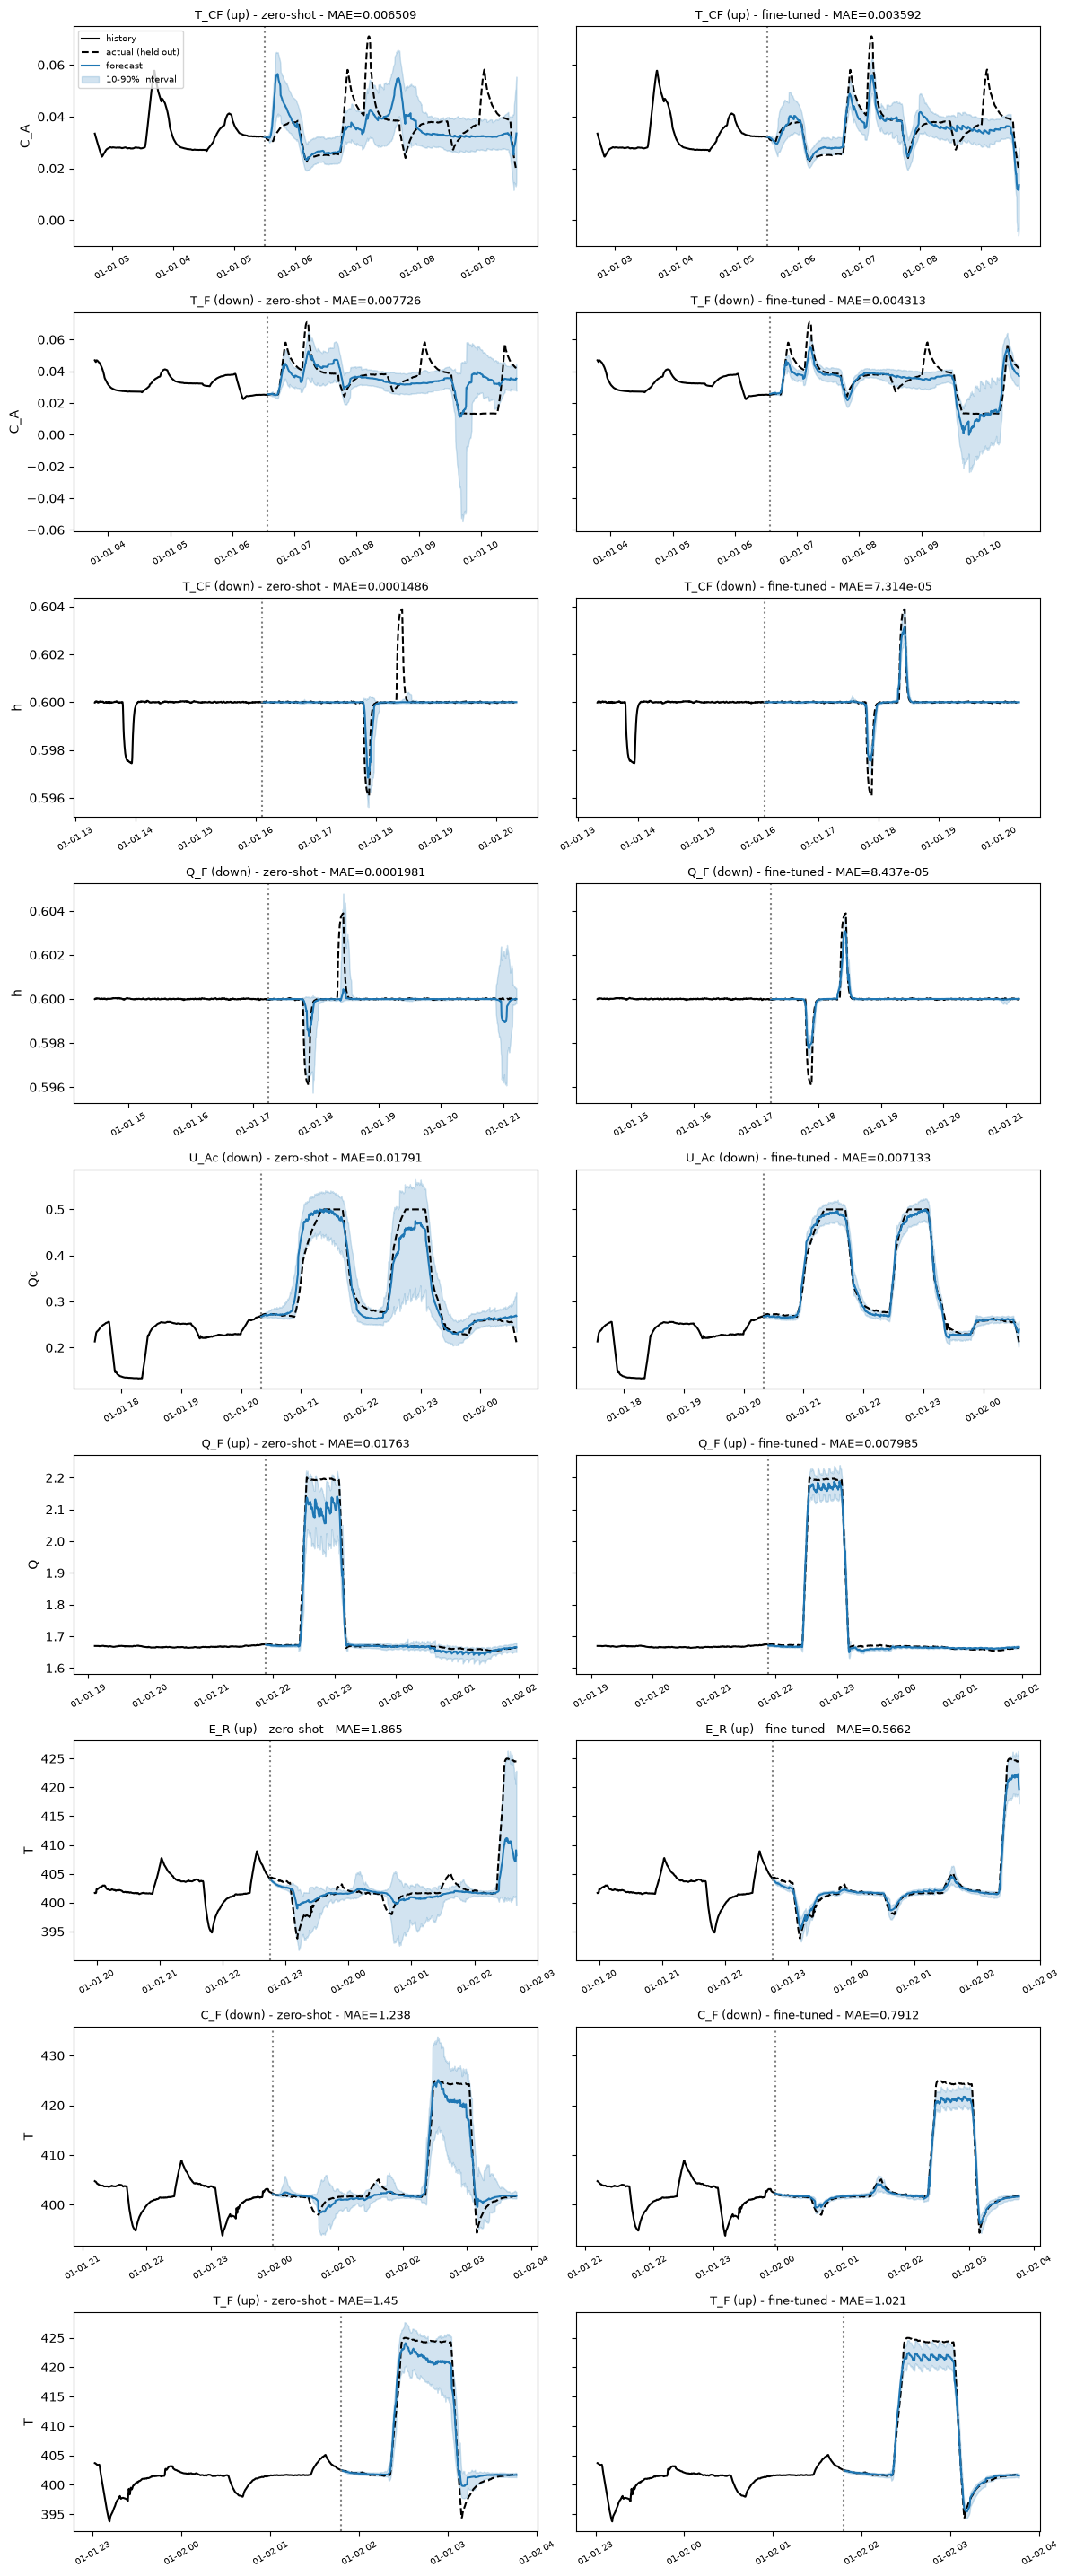

In [5]:
# %% Grid of plots: rows = events, left column = zero-shot, right column = fine-tuned
fig, axes = plt.subplots(len(rows), 2, figsize=(12, 3.2 * len(rows)), squeeze=False, sharey="row")
for r, row in enumerate(rows):
    context_tail = row["context_df"].iloc[-PLOT_LEAD_IN:]
    truth_df = row["truth_df"]
    for c, label in enumerate(["zero-shot", "fine-tuned"]):
        ax = axes[r][c]
        sub, mae = row["preds"][label]
        ax.plot(context_tail["timestamp"], context_tail[row["state"]], color="black", label="history")
        ax.plot(truth_df["timestamp"], truth_df[row["state"]], color="black", linestyle="--", label="actual (held out)")
        ax.plot(sub["timestamp"], sub["predictions"], color="tab:blue", label="forecast")
        ax.fill_between(sub["timestamp"], sub["0.1"], sub["0.9"], color="tab:blue", alpha=0.2, label="10-90% interval")
        ax.axvline(truth_df["timestamp"].iloc[0], color="gray", linestyle=":")
        direction = "up" if row["direction"] > 0 else "down"
        ax.set_title(f"{row['fault']} ({direction}) - {label} - MAE={mae:.4g}", fontsize=9)
        ax.tick_params(axis="x", rotation=30, labelsize=7)
    axes[r][0].set_ylabel(row["state"])
axes[0][0].legend(fontsize=7, loc="upper left")
fig.tight_layout()